# 05 — Evaluation, Error Analysis & Final Model Selection

Selection criterion: **lowest MAE on the unseen grouped test set**.

This notebook also reports RMSE, R², RMSLE, MAE by price tier, MAE by major brand, residual diagnostics, and model feature importance.

In [1]:
from pathlib import Path
import sys, json, os

def _find_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "data" / "bonbanh_usedcar_dataset.csv").exists() and (p / "src").exists():
            return p
    raise FileNotFoundError("Project root not found. Keep notebooks inside the CarValue_AI_Complete_Project folder.")

PROJECT_ROOT = _find_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: /mnt/data/CarValue_AI_Complete_Project_v2


In [2]:
import json, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.carvalue_utils import (
    ensure_modeling_artifacts, get_train_test, TARGET, load_bundle,
    train_price_tier_thresholds, apply_price_tier, regression_metrics, FEATURES
)

model_df, reference_year = ensure_modeling_artifacts(PROJECT_ROOT)
train, test = get_train_test(model_df)

base = pd.read_csv(PROJECT_ROOT / "artifacts" / "metrics_baseline.csv")
advanced = pd.read_csv(PROJECT_ROOT / "artifacts" / "metrics_advanced.csv")
metrics = pd.concat([base, advanced], ignore_index=True).sort_values("MAE_VND").reset_index(drop=True)
metrics.to_csv(PROJECT_ROOT / "artifacts" / "metrics_summary.csv", index=False)
display(metrics[["Model","MAE_million_VND","RMSE_million_VND","R2","RMSLE","Train_seconds"]].round(4))


,Model,MAE_million_VND,RMSE_million_VND,R2,RMSLE,Train_seconds
0,Random Forest,68.2606,202.1760,0.9751,0.1372,1.1964
1,XGBoost,77.2358,247.4840,0.9627,0.1376,0.5377
2,CatBoost,91.5616,266.3580,0.9568,0.1374,6.2338
3,Ridge Regression,141.5643,456.6853,0.8729,0.2075,0.1389
4,Median Baseline,628.5837,1343.9072,-0.1009,0.9065,0.0000


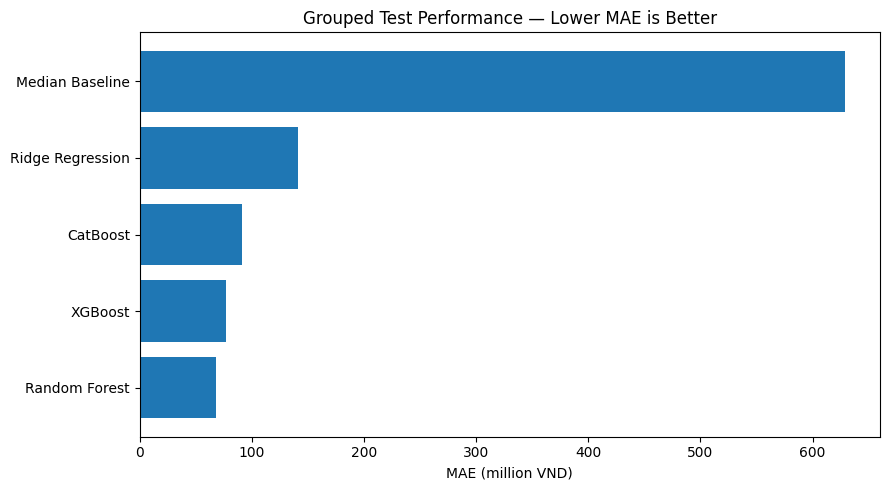

In [3]:
# Plot model comparison
fig, ax = plt.subplots(figsize=(9,5))
plot_df = metrics.sort_values("MAE_million_VND")
ax.barh(plot_df["Model"], plot_df["MAE_million_VND"])
ax.set_xlabel("MAE (million VND)")
ax.set_title("Grouped Test Performance — Lower MAE is Better")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "figures" / "model_comparison_mae.png", dpi=160, bbox_inches="tight")
plt.show()


In [4]:
bundle_files = {
    "Ridge Regression": "ridge.joblib",
    "Random Forest": "random_forest.joblib",
    "XGBoost": "xgboost.joblib",
    "CatBoost": "catboost.joblib",
}
eligible = metrics[metrics["Model"].isin(bundle_files)].copy()
best_name = eligible.sort_values("MAE_VND").iloc[0]["Model"]
best_path = PROJECT_ROOT / "models" / bundle_files[best_name]
best = load_bundle(best_path)
y_true = test[TARGET].to_numpy(float)
y_pred = best.predict(test)
print("Selected final model:", best_name)
print(regression_metrics(y_true, y_pred))


Selected final model: Random Forest
{'MAE_VND': 68260628.37557736, 'MAE_million_VND': 68.26062837557735, 'RMSE_VND': 202176038.06811827, 'RMSE_million_VND': 202.1760380681183, 'R2': 0.9750849993472962, 'RMSLE': 0.13718787923288772}


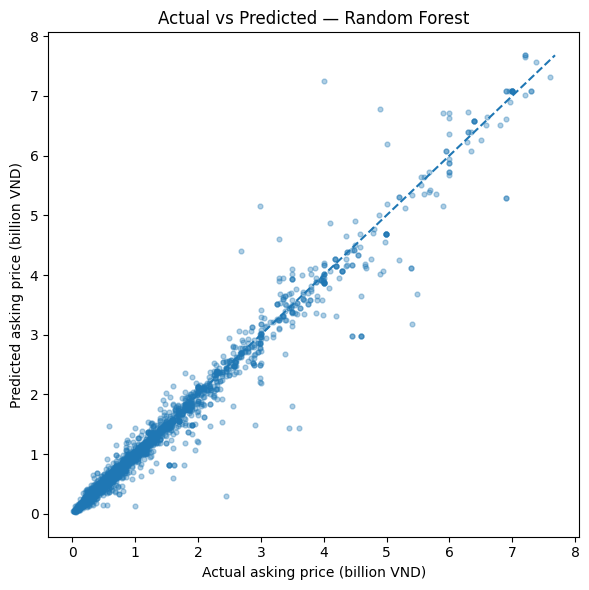

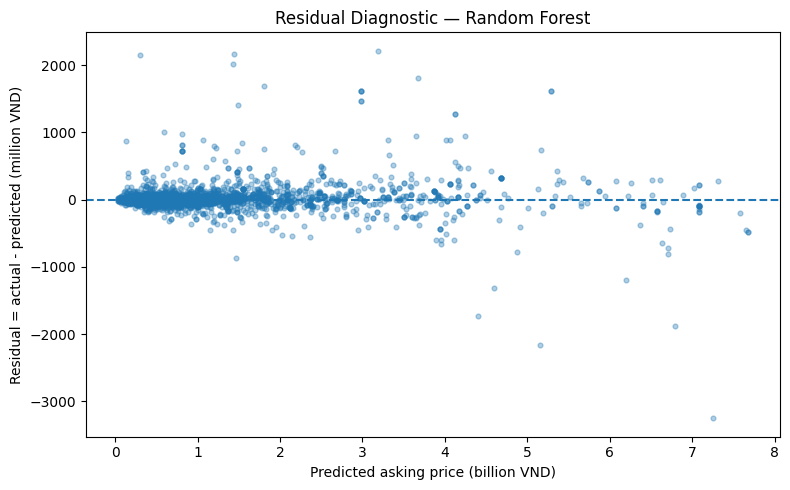

In [5]:
# Actual vs Predicted
fig, ax = plt.subplots(figsize=(6,6))
upper = np.quantile(np.r_[y_true, y_pred], 0.995)
mask = (y_true <= upper) & (y_pred <= upper)
ax.scatter(y_true[mask]/1e9, y_pred[mask]/1e9, s=12, alpha=0.35)
lim = max((y_true[mask]/1e9).max(), (y_pred[mask]/1e9).max())
ax.plot([0, lim], [0, lim], linestyle="--")
ax.set_xlabel("Actual asking price (billion VND)")
ax.set_ylabel("Predicted asking price (billion VND)")
ax.set_title(f"Actual vs Predicted — {best_name}")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "figures" / "actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()

# Residuals
residual = y_true - y_pred
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(y_pred[mask]/1e9, residual[mask]/1e6, s=12, alpha=0.35)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted asking price (billion VND)")
ax.set_ylabel("Residual = actual - predicted (million VND)")
ax.set_title(f"Residual Diagnostic — {best_name}")
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "figures" / "residuals.png", dpi=160, bbox_inches="tight")
plt.show()


In [6]:
# Error by price tier using thresholds learned from TRAIN only
thresholds = train_price_tier_thresholds(train[TARGET])
eval_df = test[["brand", TARGET]].copy()
eval_df["prediction"] = y_pred
eval_df["abs_error"] = np.abs(eval_df[TARGET] - eval_df["prediction"])
eval_df["price_tier"] = apply_price_tier(eval_df[TARGET], thresholds)

tier_mae = (eval_df.groupby("price_tier", observed=True)["abs_error"].agg(["count","mean"]).reset_index())
tier_mae["MAE_million_VND"] = tier_mae["mean"] / 1e6
tier_mae.to_csv(PROJECT_ROOT / "artifacts" / "mae_by_price_tier.csv", index=False)
display(tier_mae[["price_tier","count","MAE_million_VND"]].round(2))


,price_tier,count,MAE_million_VND
0,Entry,1201,23.81
1,Lower-mid,1151,28.50
2,Mid,1131,43.28
3,Upper,676,101.34
4,Premium,436,309.19


In [7]:
# Error by major brand
top_brands = train["brand"].value_counts().head(12).index
brand_eval = eval_df[eval_df["brand"].isin(top_brands)]
brand_mae = brand_eval.groupby("brand")["abs_error"].agg(["count","mean"]).sort_values("mean")
brand_mae["MAE_million_VND"] = brand_mae["mean"] / 1e6
brand_mae.to_csv(PROJECT_ROOT / "artifacts" / "mae_by_major_brand.csv")
display(brand_mae[["count","MAE_million_VND"]].round(2))


,count,MAE_million_VND
brand,,
Honda,178,24.82
Mazda,299,26.13
Hyundai,466,27.82
VinFast,312,28.44
Kia,421,29.25
Mitsubishi,178,36.56
Ford,405,40.18
Toyota,778,55.67
Mercedes-Benz,539,83.59


,feature,importance
0,num__car_age,0.264396
12,cat__drivetrain,0.250404
3,num__engine_size_l,0.237202
6,cat__model,0.067277
9,cat__transmission,0.051230
5,cat__brand,0.029269
1,num__mileage_km,0.022511
8,cat__body_type,0.021403
7,cat__origin,0.019551
4,num__seats,0.018747


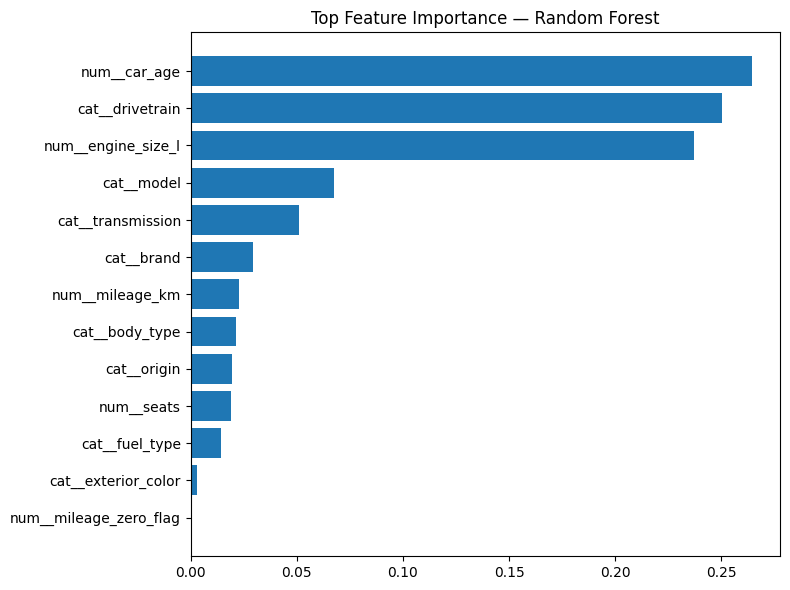

In [8]:
# Feature importance / coefficient magnitude
names, values = None, None
if best.kind == "catboost_native" and hasattr(best.model, "feature_importances_"):
    names = FEATURES
    values = np.asarray(best.model.feature_importances_)
elif hasattr(best.model, "feature_importances_"):
    names = list(best.preprocessor.get_feature_names_out())
    values = np.asarray(best.model.feature_importances_)
elif hasattr(best.model, "coef_"):
    names = list(best.preprocessor.get_feature_names_out())
    values = np.abs(np.ravel(best.model.coef_))

if names is not None:
    imp = pd.DataFrame({"feature": names, "importance": values}).sort_values("importance", ascending=False).head(20)
    imp.to_csv(PROJECT_ROOT / "artifacts" / "feature_importance_top20.csv", index=False)
    display(imp)
    fig, ax = plt.subplots(figsize=(8,6))
    p = imp.sort_values("importance")
    ax.barh(p["feature"], p["importance"])
    ax.set_title(f"Top Feature Importance — {best_name}")
    fig.tight_layout()
    fig.savefig(PROJECT_ROOT / "figures" / "feature_importance.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Feature importance is not available for this model.")


In [9]:
# Freeze the evaluated winner as final_model.joblib
final_path = PROJECT_ROOT / "models" / "final_model.joblib"
shutil.copy2(best_path, final_path)
selected_row = metrics.loc[metrics["Model"].eq(best_name)].iloc[0].to_dict()
meta = {
    "selected_model": best_name,
    "selection_rule": "Lowest MAE on unseen group-aware test split",
    "reference_year": int(reference_year),
    "test_metrics": {k: (float(v) if isinstance(v, (int,float,np.integer,np.floating)) else v) for k,v in selected_row.items() if k != "Model"},
    "price_tier_thresholds_vnd": thresholds,
}
with open(PROJECT_ROOT / "models" / "final_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print("Final model frozen:", final_path)
print(json.dumps(meta, ensure_ascii=False, indent=2))


Final model frozen: /mnt/data/CarValue_AI_Complete_Project_v2/models/final_model.joblib
{
  "selected_model": "Random Forest",
  "selection_rule": "Lowest MAE on unseen group-aware test split",
  "reference_year": 2026,
  "test_metrics": {
    "MAE_VND": 68260628.37557736,
    "MAE_million_VND": 68.26062837557735,
    "RMSE_VND": 202176038.0681184,
    "RMSE_million_VND": 202.17603806811843,
    "R2": 0.9750849993472962,
    "RMSLE": 0.1371878792328877,
    "Train_seconds": 1.1964435360000607
  },
  "price_tier_thresholds_vnd": {
    "q25": 356000000.0,
    "q50": 560000000.0,
    "q75": 1000000000.0,
    "q90": 2250000000.0
  }
}
